# XGBoost Sybil Detector — LayerZero

Reproduces the tuned XGBoost model from:
> *Sybil Detection on Public Blockchains via XGBoost and Gas Provision Network Analysis*

**Configuration**: hyperparameters selected on validation by `05_hyperparameter_search`
(printed in section 5); 3-seed ensemble (seeds 42, 123, 456); 5,000 round ceiling with
`early_stopping_rounds=50`.

**Results**: test metrics are printed in section 6 and saved to `results/01_xgboost_<split>.json`;
`06_split_comparison` tabulates both splits.

## 1. Setup

In [1]:
# Install required packages (run once)
# !pip install xgboost lightgbm scikit-learn pandas numpy matplotlib

In [2]:
import os, time, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve, roc_curve, auc,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    brier_score_loss, average_precision_score
)

import sybil_pipeline as sp

warnings.filterwarnings('ignore')
SEED = sp.SEED

In [3]:
# ── Set this to the folder containing all data files ──────────
DATA_DIR = './data'   # <-- adjust if needed

# 'group'  = stratified group split by funding cluster (revision default)
# 'random' = address-level split used in the original paper
SPLIT_METHOD = os.environ.get('SPLIT_METHOD', 'group')

FEATS = sp.FEATS   # 62 model features (defined in sybil_pipeline.py)
print(f'Split method: {SPLIT_METHOD}  |  {len(FEATS)} features')

Split method: group  |  62 features


## 2. Data Loading

Seven steps: L0 base features → gas provision mapping → labeled anchor streaming → tree topology → CEX/DEX counts → Sybil labels → chain traversal.

In [4]:
# ── Build the master feature table (steps 1-7; see 00_data_pipeline) ──
df, tfm, labeled_anchors = sp.build_master_df(DATA_DIR)

[1] L0 features: 434,786 addresses, 55 cols


[2] Gas provision: 604,365 edges before 2024-05-02 00:00:00 UTC (296 later edges dropped)


[3] Labeled addresses in provision network: 4,308


[4] Provider and tree features: 88 cols


[5] CEX/DEX merged: 90 cols


[6] Labels: Sybil=18,211 (4.19%)


[7] Chain features, taxonomy, funding groups (371,764 groups)


All 62 features present ✓  (43.8s)


## 3. Train / Validation / Test Split

In [5]:
# ── Train / Val / Test split + minority upsampling ────────────
# 49 / 21 / 30 partitions. With SPLIT_METHOD='group', no funding group
# spans two partitions (asserted inside sp.make_splits).
S = sp.make_splits(df, FEATS, method=SPLIT_METHOD, seed=SEED)
X_train, y_train = S['X_train'], S['y_train']
X_val,   y_val   = S['X_val'],   S['y_val']
X_test,  y_test  = S['X_test'],  S['y_test']

print(sp.split_summary(df, S).to_string(index=False))
print(f'Train after upsampling: {len(X_train):,} rows ({y_train.mean()*100:.1f}% Sybil)\n')
leak = sp.leakage_report(df, S)

     Split  Total  Sybil  NonSybil  SybilPct
     Train 213046   8924    204122      4.19
Validation  91305   3824     87481      4.19
      Test 130435   5463    124972      4.19
Train after upsampling: 408,244 rows (50.0% Sybil)



Split method: group
Row overlap (train/val, train/test, val/test): 0, 0, 0
Test addresses sharing a funding group with a train address: 0 / 130,435
Test Sybils sharing a funding group with a train Sybil:     0 / 5,463


## 4. Evaluation Helpers

In [6]:
# ── Evaluation helpers ────────────────────────────────────────
def optimal_threshold(y_true, probs):
    """Find threshold that maximises F1 on the given set."""
    prec, rec, thresholds = precision_recall_curve(y_true, probs)
    f1 = np.where((prec + rec) > 0, 2 * prec * rec / (prec + rec), 0)
    return float(thresholds[np.argmax(f1[:-1])])

def evaluate(name, val_probs, test_probs, y_val, y_test, threshold=None):
    """Evaluate model at optimal val threshold, report test metrics."""
    thr = threshold if threshold is not None else optimal_threshold(y_val, val_probs)
    y_pred = (test_probs >= thr).astype(int)
    fpr, tpr, _ = roc_curve(y_test, test_probs)
    prc, rec, _ = precision_recall_curve(y_test, test_probs)
    results = dict(
        name      = name,
        threshold = thr,
        precision = precision_score(y_test, y_pred, zero_division=0),
        recall    = recall_score(y_test, y_pred,    zero_division=0),
        f1        = f1_score(y_test, y_pred,         zero_division=0),
        auroc     = auc(fpr, tpr),
        ap        = average_precision_score(y_test, test_probs),
        brier     = brier_score_loss(y_test, test_probs),
        fpr=fpr, tpr=tpr, prc=prc, rec_c=rec,
    )
    print(f'  Threshold : {thr:.4f}')
    print(f'  Precision : {results["precision"]:.4f}')
    print(f'  Recall    : {results["recall"]:.4f}')
    print(f'  F1        : {results["f1"]:.4f}')
    print(f'  AUROC     : {results["auroc"]:.4f}')
    print(f'  Avg Prec  : {results["ap"]:.4f}')
    print(f'  Brier     : {results["brier"]:.4f}')
    print(classification_report(y_test, y_pred, digits=4))
    return results

def plot_curves(results_list):
    """Plot ROC and PR curves for one or more models."""
    colors = ['#1565C0','#2E7D32','#B71C1C','#6A1B9A','#E65100']
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for r, c in zip(results_list, colors):
        axes[0].plot(r['fpr'], r['tpr'], color=c, lw=2,
                     label=f"{r['name']}  AUC={r['auroc']:.4f}")
        axes[1].plot(r['rec_c'], r['prc'], color=c, lw=2,
                     label=f"{r['name']}  AP={r['ap']:.4f}")
    axes[0].plot([0,1],[0,1],'k--',alpha=0.3,lw=1)
    axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curve')
    axes[0].legend(fontsize=9); axes[0].grid(alpha=0.2)
    axes[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall Curve')
    axes[1].legend(fontsize=9, loc='upper right'); axes[1].grid(alpha=0.2)
    plt.tight_layout(); plt.show()

## 5. Train XGBoost (3-Seed Ensemble)

In [7]:
from xgboost import XGBClassifier

# ── Hyperparameters: selected on validation by 05_hyperparameter_search ──
XGB_SELECTED, _ = sp.load_selected_params()
XGB_PARAMS = dict(
    objective         = 'binary:logistic',
    n_estimators      = 5000,          # hard ceiling; early stopping controls actual rounds
    eval_metric       = 'logloss',
    early_stopping_rounds = 50,
    verbosity         = 0,
    n_jobs            = sp.N_JOBS,     # fixed: 'hist' results depend on thread count
    **XGB_SELECTED,
)
print('XGBoost params:', XGB_PARAMS)

# ── 3-seed ensemble (averages variance across random initialisations) ──
SEEDS = [42, 123, 456]
val_probs_list  = []
test_probs_list = []
rounds = []
models = []

for seed in SEEDS:
    print(f'Training seed={seed}...', flush=True)
    t0 = time.time()
    model = XGBClassifier(**XGB_PARAMS, random_state=seed, tree_method='hist')
    model.fit(X_train, y_train,
              eval_set=[(X_val, y_val)],
              verbose=False)
    rounds.append(int(model.best_iteration))
    models.append(model)
    val_probs_list.append(model.predict_proba(X_val)[:,1])
    test_probs_list.append(model.predict_proba(X_test)[:,1])
    print(f'  best_iteration={model.best_iteration}  time={time.time()-t0:.1f}s')

xgb_val_probs  = np.mean(val_probs_list,  axis=0)
xgb_test_probs = np.mean(test_probs_list, axis=0)
print('\nEnsemble probabilities computed.')

XGBoost params: {'objective': 'binary:logistic', 'n_estimators': 5000, 'eval_metric': 'logloss', 'early_stopping_rounds': 50, 'verbosity': 0, 'n_jobs': 4, 'learning_rate': 0.05, 'max_depth': 8, 'subsample': 0.7, 'colsample_bytree': 1.0, 'min_child_weight': 1}
Training seed=42...


  best_iteration=1679  time=80.4s
Training seed=123...


  best_iteration=1617  time=76.3s
Training seed=456...


  best_iteration=1578  time=77.3s

Ensemble probabilities computed.


## 6. Evaluate on Test Set

=== XGBoost 3-Seed Ensemble — Test Set Results ===


  Threshold : 0.5824
  Precision : 0.7196
  Recall    : 0.7205
  F1        : 0.7200
  AUROC     : 0.9657
  Avg Prec  : 0.7645
  Brier     : 0.0197
              precision    recall  f1-score   support

           0     0.9878    0.9877    0.9878    124972
           1     0.7196    0.7205    0.7200      5463

    accuracy                         0.9765    130435
   macro avg     0.8537    0.8541    0.8539    130435
weighted avg     0.9765    0.9765    0.9765    130435



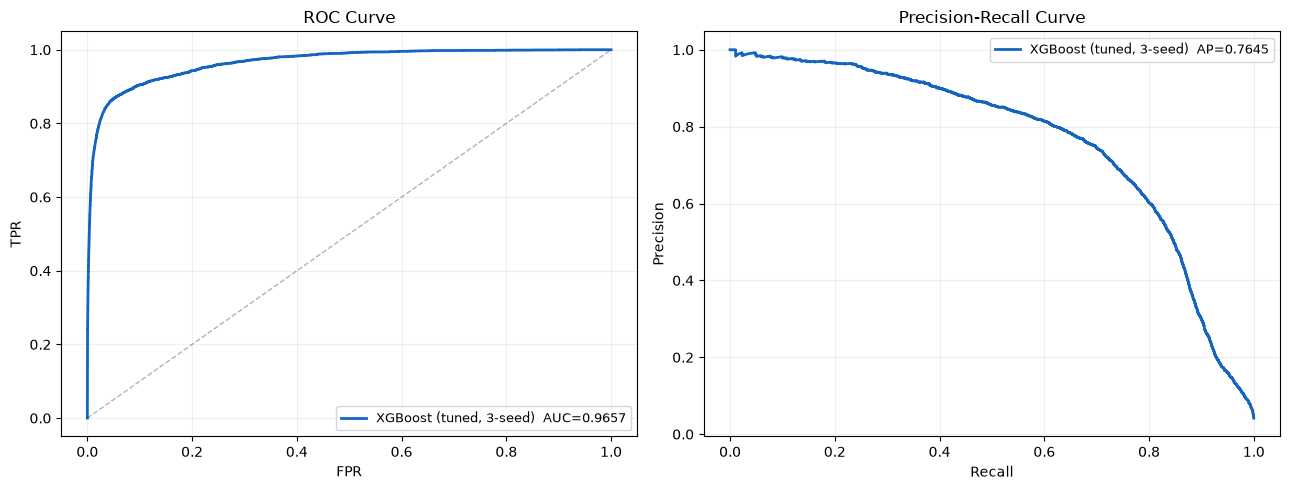

In [8]:
print('=== XGBoost 3-Seed Ensemble — Test Set Results ===')
xgb_results = evaluate('XGBoost (tuned, 3-seed)',
                        xgb_val_probs, xgb_test_probs, y_val, y_test)
plot_curves([xgb_results])

## 7. Feature Importances

Total gain: the reduction in training loss summed over every split on the feature, normalized to sum to 1
for each model and averaged over the three seeds. Gain credits correlated features unevenly;
`10_shap_importance` reports SHAP values and sums them by feature family.

Top 20 features (normalized total gain, mean over 3 seeds):
                          Feature  NormGain
                  l0_tx_time_span  0.225214
              num_transactions_in  0.082668
             l0_avg_stargate_swap  0.063265
            n_l0_source_contracts  0.049595
              earliest_l0_tx_time  0.048238
                 max_tx_value_out  0.045587
                latest_l0_tx_time  0.041518
             earliest_tx_block_in  0.040433
       gas_provision_block_number  0.033138
           tx_value_per_block_out  0.032809
                     time_span_in  0.030862
               n_l0_source_chains  0.030242
                  min_tx_value_in  0.025118
    n_l0_project_per_source_chain  0.023459
                    n_l0_projects  0.017038
                 provider_fan_out  0.013623
                 min_tx_value_out  0.013071
provider_min_gas_provision_amount  0.012781
               n_eth_interactions  0.011782
provider_avg_gas_provision_amount  0.011598


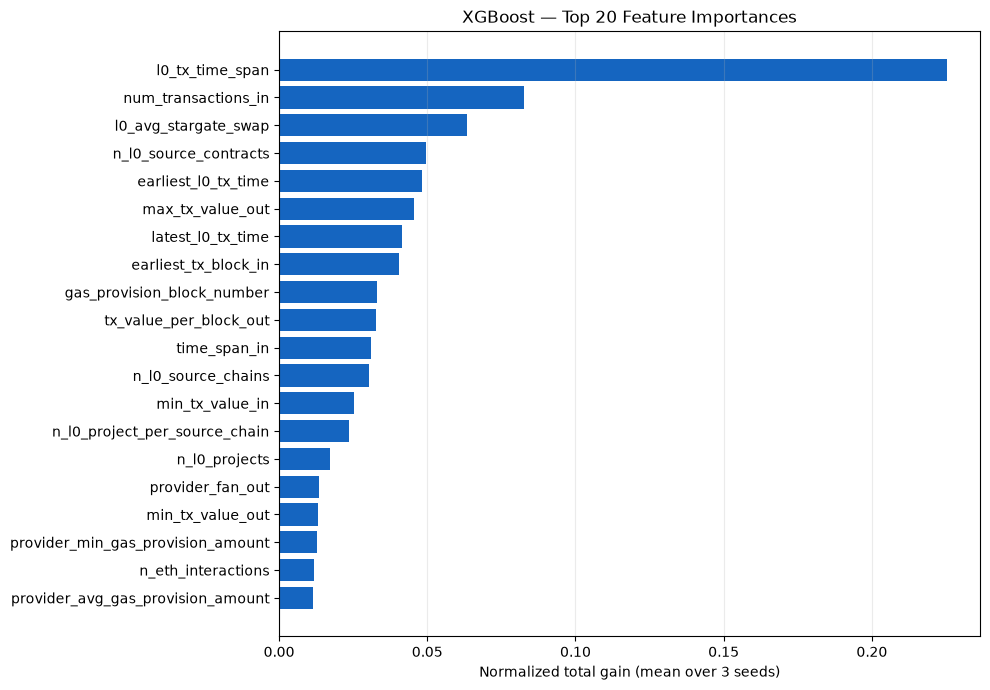

In [9]:
# ── Feature importance: total gain, normalized per model, mean over the 3 seeds ──
imp = []
for m in models:
    g = m.get_booster().get_score(importance_type='total_gain')   # features never split on are absent
    v = np.array([g.get(f, g.get(f'f{i}', 0.0)) for i, f in enumerate(FEATS)])
    imp.append(v / v.sum())
imp_df = pd.DataFrame({'Feature': FEATS, 'NormGain': np.mean(imp, axis=0)})
imp_df = imp_df.sort_values('NormGain', ascending=False).reset_index(drop=True)
print('Top 20 features (normalized total gain, mean over 3 seeds):')
print(imp_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 7))
top20 = imp_df.head(20)
ax.barh(top20['Feature'][::-1], top20['NormGain'][::-1], color='#1565C0')
ax.set(xlabel='Normalized total gain (mean over 3 seeds)',
       title='XGBoost — Top 20 Feature Importances')
ax.grid(axis='x', alpha=0.25)
plt.tight_layout(); plt.show()

## 8. Operating Point Table

In [10]:
# ── Operating point table ─────────────────────────────────────
n_sybil = int(y_test.sum()); n_clean = len(y_test) - n_sybil
print(f'\nTest set: {len(y_test):,} total | {n_sybil:,} Sybil | {n_clean:,} Non-Sybil\n')
print(f'  {"Threshold":<10} {"Precision":<11} {"Recall":<10} {"F1":<9} {"Flagged":<11} {"False+"}')
print('-'*65)
thr = xgb_results['threshold']   # chosen on validation; its row equals the reported test metrics
for t in sorted({0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.50, thr}, reverse=True):
    y_pred = (xgb_test_probs >= t).astype(int)
    if y_pred.sum() == 0: continue
    tp_ = int(((y_pred==1)&(y_test==1)).sum()); fp_ = int(((y_pred==1)&(y_test==0)).sum())
    p = tp_/(tp_+fp_); r = tp_/n_sybil; f1v = 2*p*r/(p+r) if p+r>0 else 0
    mark = '  <- validation threshold' if t == thr else ''
    print(f'  {t:<10.4f} {p:<11.4f} {r:<10.4f} {f1v:<9.4f} {y_pred.sum():<11,} {fp_:,}{mark}')


Test set: 130,435 total | 5,463 Sybil | 124,972 Non-Sybil

  Threshold  Precision   Recall     F1        Flagged     False+
-----------------------------------------------------------------
  0.9500     0.8636      0.4843     0.6206    3,064       418
  0.9000     0.8299      0.5682     0.6746    3,740       636
  0.8500     0.8075      0.6105     0.6953    4,130       795
  0.8000     0.7913      0.6372     0.7059    4,399       918
  0.7500     0.7743      0.6614     0.7134    4,666       1,053
  0.7000     0.7575      0.6833     0.7185    4,928       1,195
  0.5824     0.7196      0.7205     0.7200    5,470       1,534  <- validation threshold
  0.5000     0.6935      0.7388     0.7154    5,820       1,784


## Save Results

Scalar metrics go to `results/<notebook>_<split>.json` with the code commit, so every number in the paper can be traced to one run.

In [11]:
sp.save_results([xgb_results], '01_xgboost', SPLIT_METHOD, leakage=leak,
                extra=dict(params=XGB_SELECTED, rounds=rounds,
                           importance=imp_df.set_index('Feature')['NormGain'].to_dict()))

# ── Test predictions (read by 06_split_comparison for per-category metrics) ──
os.makedirs('output', exist_ok=True)
pred = pd.DataFrame({'addr': df.loc[S['idx_test'], 'addr'].to_numpy(),
                     'category': df.loc[S['idx_test'], 'category'].to_numpy(),
                     'y': y_test.to_numpy(), 'prob_xgb': xgb_test_probs})
pred.to_parquet(f'output/pred_01_xgboost_{SPLIT_METHOD}.parquet', index=False)
print(f'Saved output/pred_01_xgboost_{SPLIT_METHOD}.parquet ({len(pred):,} rows)')

Saved results/01_xgboost_group.json
Saved output/pred_01_xgboost_group.parquet (130,435 rows)
